In [4]:
# QUESTION 1
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data = load_breast_cancer()

X = data["data"]
y = data["target"]

X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['label'] = data.target_names[data.target]

print(X.shape)
print(y.shape)

# There are 569 patients and 30 features.

print(df['label'].value_counts())

# There are 357 patients with benign tumors
# There are 212 patients with malignant

# This data set would be imbalanced, as there are 145 more patients 
# with benign tumors than malignant.

# Class balance is important because the learning model with favor \
# the class with more data points, creating inacuracies inside the
# machine learning.




(569, 30)
(569,)
label
benign       357
malignant    212
Name: count, dtype: int64


In [5]:
# QUESTION 2
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer

scaler = StandardScaler()

data = load_breast_cancer()

X = data["data"]
y = data["target"]

X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['label'] = data.target_names[data.target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(criterion='entropy', random_state=42)

model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# The entropy represents the decisive accuracy of choosing the right
# partition for each question in the decision tree. 

# There is a touch of over-fitting, but not horrible if the 
# test accuracy is only 5% off the training accuracy. 

Training Accuracy: 1.0
Test Accuracy: 0.9473684210526315


In [15]:
# QUESTION 3
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target
df['label'] = data.target_names[data.target]

X = df.drop(columns=['target', 'label'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_constrained = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)
model_constrained.fit(X_train, y_train)

importances = model_constrained.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

top5 = feature_importance_df.sort_values(by='importance', ascending=False).head(5)

print("Top 5 features:")
print(top5)

# In decision Trees, if the training accuracy is really high or 1.0,
# then the test accuracy will be noticibly lower. Also, this happens
# more often the deeper the tree. 

# Feature importance tells you which features are most used to justify
# each decision. This can be helpful when debunking which variable has
# most effect on the outcome. 

Top 5 features:
                feature  importance
7   mean concave points    0.665589
22      worst perimeter    0.119098
20         worst radius    0.089418
21        worst texture    0.073792
1          mean texture    0.027677


In [16]:
# QUESTION 4
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.neural_network import MLPClassifier

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target
df['label'] = data.target_names[data.target]

X = df.drop(columns=['target', 'label'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_constrained = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(10,),   
    activation='relu',          
    solver='adam',
    max_iter=1000,
    random_state=42
)


nn_model.fit(X_train_scaled, y_train)

train_acc = nn_model.score(X_train_scaled, y_train)
test_acc = nn_model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Feature scaling in neural networks in necessary because training can
# become unbalance when the scales of each feature a skewed. 

# An epoch represents one pass through of the entire training dataset.

Training Accuracy: 0.9912087912087912
Test Accuracy: 0.9824561403508771


In [20]:
# QUESTION 5
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.neural_network import MLPClassifier

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target
df['label'] = data.target_names[data.target]

X = df.drop(columns=['target', 'label'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_constrained = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(10,),   
    activation='relu',          
    solver='adam',
    max_iter=1000,
    random_state=42
)


nn_model.fit(X_train_scaled, y_train)
model_constrained.fit(X_train, y_train)
y_pred_tree = model_constrained.predict(X_test)

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

y_pred_nn = nn_model.predict(X_test_scaled)

cm_nn = confusion_matrix(y_test, y_pred_nn)

print("\nNeural Network Confusion Matrix:")
print(cm_nn)

# I would prefer Neural Network because it has more accurate testing.
# The limitation of the decision tree tends to overfit in this case.
# The limitation of the neural network is it can be hard to track how
# the model makes its predictions. 
# An advantage for the decsion tree is it can be visualized.
# An advantage of a neural net, is that it is usually more accurate. 

Decision Tree Confusion Matrix:
[[39  4]
 [ 0 71]]

Neural Network Confusion Matrix:
[[42  1]
 [ 1 70]]


In [23]:
# QUESTION 6
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# CNN's are preferred because less parameters are needed and the CNN
# knows where the density is.

# The convolution layer learns patterns in the image.

C:\Users\nolan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8444 - loss: 0.4444 - val_accuracy: 0.8707 - val_loss: 0.3675
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8902 - loss: 0.3165 - val_accuracy: 0.8872 - val_loss: 0.3193
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9011 - loss: 0.2812 - val_accuracy: 0.8866 - val_loss: 0.3089
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9082 - loss: 0.2579 - val_accuracy: 0.8909 - val_loss: 0.3003
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9155 - loss: 0.2388 - val_accuracy: 0.8949 - val_loss: 0.2946
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9203 - loss: 0.2244 - val_accuracy: 0.9031 - val_loss: 0.2732
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9260 - loss: 0.2107 - val_accuracy: 0.9011 - val_loss: 0.2840
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9287 - loss: 0.1991 -

 34/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

C:\Users\nolan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 10)
[[  2  97   1   0   0   4   0 815  23  58]
 [  2   6   0   0   0   0   0 756   8 228]
 [  2 358   0   0   2   7   0 580  26  25]
 [  1  28   2   2   1   7   0 689  32 238]
 [  2 296   0   0   0  10   0 636  23  33]
 [114 388 139   5  10   1   0 190  45 108]
 [  1 338   1   0   0   5   0 614  15  26]
 [184  49  33   0   1   0   0 538 117  78]
 [136 421  21   0   0   2   0 321  32  67]
 [204 670   1   0   0   0   0  81  25  19]]


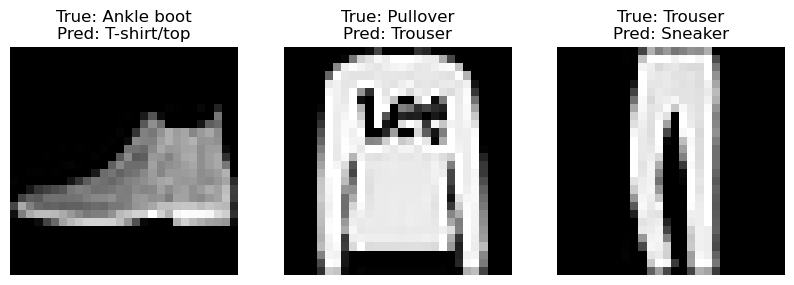

In [28]:
# QUESTION 7
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

y_predict = model.predict(X_test)
print(y_predict.shape)

y_pred_classes = np.argmax(y_predict, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

misclassified_indices = np.where(y_pred_classes != y_test)[0]
sample_indices = misclassified_indices[:3]

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10,4))

for i, idx in enumerate(sample_indices):
    plt.subplot(1, 3, i+1)
    
    
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')

plt.show()

# A pattern that I have obserbed in the misclassified images is the
# predictions are a different piece of clothing than the true. 

# A method that would improve the CNN